# Mean-centred PLS vs effect-matched-spatial filtering (EMS)

Effect-matched-spatial filtering (EMS; [Schurger et al., 2013](https://doi.org/10.1186/1471-2202-14-122)) is a technique that projects multi-channel EEG data onto a single time series that differentiates between conditions. This is quite similar to the concept of temporal brain scores in PLS, and as this tutorial demonstrates, the two techniques yield similar results.

## Loading and preprocessing the data

We will begin by loading the MNE example data and preprocessing it following the [MNE tutorial on EMS](https://mne.tools/stable/auto_examples/decoding/ems_filtering.html):

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold

import mne
from mne import EvokedArray, io
from mne.datasets import sample
from mne.decoding import EMS, compute_ems

import mne_plsc

data_path = sample.data_path()

# Preprocess the data
meg_path = data_path / "MEG" / "sample"
raw_fname = meg_path / "sample_audvis_filt-0-40_raw.fif"
event_fname = meg_path / "sample_audvis_filt-0-40_raw-eve.fif"
event_ids = {"AudL": 1, "VisL": 3}

# Read data and create epochs
raw = io.read_raw_fif(raw_fname, preload=True)
raw.filter(0.5, 45, fir_design="firwin")
events = mne.read_events(event_fname)

raw.pick(["grad", "eog"], exclude="bads")

epochs = mne.Epochs(
    raw,
    events,
    event_ids,
    tmin=-0.2,
    tmax=0.5,
    baseline=None,
    preload=True,
)
epochs = epochs.pick("grad")

Opening raw data file C:\Users\isaac\mne_data\MNE-sample-data\MEG\sample\sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.
Reading 0 ... 41699  =      0.000 ...   277.709 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 993 samples (6.613 s)

Not setting metadata
145 matc

## EMS

The following code implements EMS succinctly---see the MNE tutorial for details. After fitting the model, we plot the single-trial timecourses as well as their averages by condition.

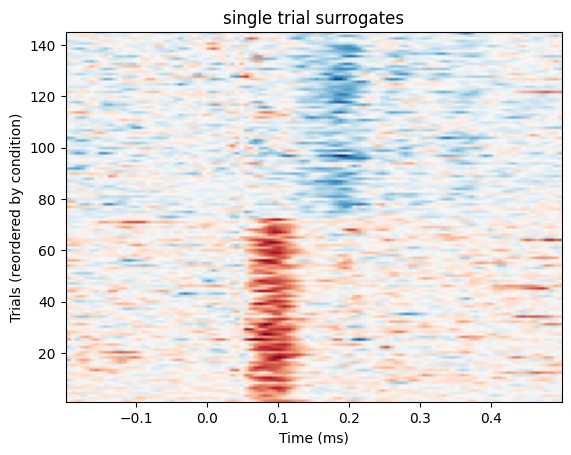

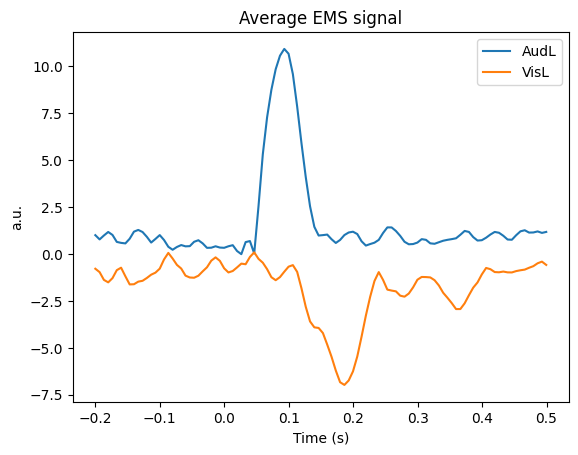

In [13]:
X = epochs.get_data(copy=False)
y = epochs.events[:, 2]
n_epochs, n_channels, n_times = X.shape
ems = EMS()
X_transform = np.zeros((n_epochs, n_times))
for train, test in StratifiedKFold(n_splits=5).split(X, y):
    X_scaled = X / np.std(X[train])
    ems.fit(X_scaled[train], y[train])
    X_transform[test] = ems.transform(X_scaled[test])
# Plot single-trial timecourses
plt.figure()
plt.title("single trial surrogates")
vlim = np.abs(X_transform).max()
plt.imshow(
    X_transform[y.argsort()],
    origin="lower",
    aspect="auto",
    extent=[epochs.times[0], epochs.times[-1], 1, len(X_transform)],
    cmap="RdBu_r",
    vmin=-vlim,
    vmax=vlim
)
plt.xlabel("Time (s)")
plt.ylabel("Trials (reordered by condition)")
# Plot average response
plt.figure()
plt.title("Average EMS signal")
mappings = [(key, value) for key, value in event_ids.items()]
for key, value in mappings:
    ems_ave = X_transform[y == value]
    plt.plot(epochs.times, ems_ave.mean(0), label=key)
plt.xlabel("Time (s)")
plt.ylabel("a.u.")
plt.legend()
plt.show()

## Mean-centred PLS

Next, we will fit a mean-centred PLS model and similarly plot the trial- and condition-wise temporal brain scores.

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Time (s)', ylabel='Brain score'>)

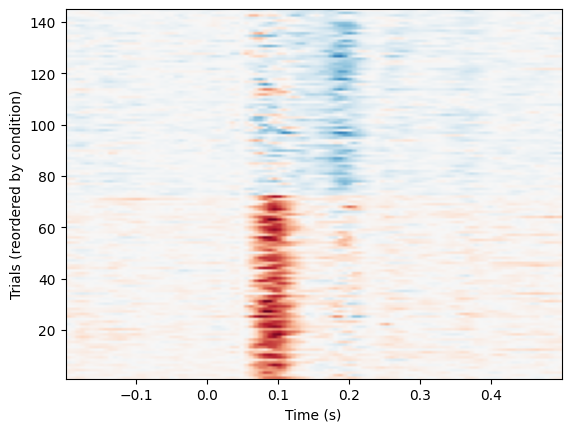

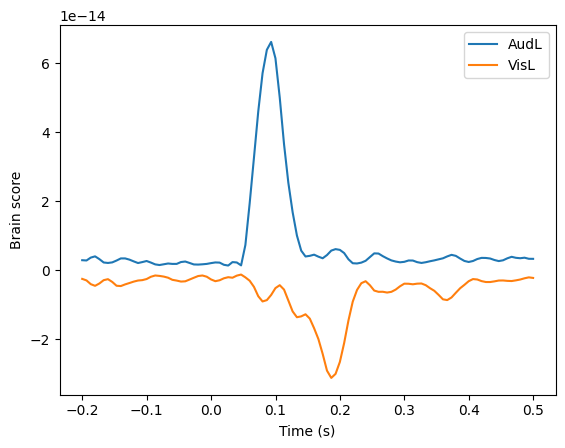

In [18]:
# Get condition labels and fit model
labels = mne_plsc.utils.get_epoch_labels(epochs)
res = mne_plsc.fit_mc(epochs, between=labels)
# Get trial-wise brain scores
scores = res.get_marginal_brain_scores(lv_idx=0, margin='time', average=False)
scores = np.stack(scores)
# Plot trial-wise brain scores
plt.figure()
plt.xlabel("Time (s)")
plt.ylabel("Trials (reordered by condition)")
vlim = np.abs(scores).max()
plt.imshow(
    scores[y.argsort()],
    origin="lower",
    aspect="auto",
    extent=[epochs.times[0], epochs.times[-1], 1, len(scores)],
    cmap="RdBu_r",
    vmin=-vlim,
    vmax=vlim
)
# PLot condition-wise averages
res.plot_marginal_brain_scores(lv_idx=0, margin='time')

As we can see, the two approaches yield strikingly similar results.